# MTA Delay Analysis (2020-2024)

In [311]:
import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns 

*Reading in data*

In [314]:
mta_data = pd.read_csv('MTA_Subway_Train_Delays.csv')

In [315]:
mta_data

,month,division,line,day_type,reporting_category,subcategory,delays
0,12/1/24,A DIVISION,1,1,Crew Availability,Crew Availability,83
1,12/1/24,A DIVISION,1,1,External Factors,External Debris on Roadbed,4
2,12/1/24,A DIVISION,1,1,Infrastructure & Equipment,Braking,37
3,12/1/24,A DIVISION,1,1,Infrastructure & Equipment,Door-Related,34
4,12/1/24,A DIVISION,1,1,Infrastructure & Equipment,"Fire, Smoke, Debris",37
...,...,...,...,...,...,...,...
40498,1/1/20,B DIVISION,S Rock,2,Infrastructure & Equipment,Service Delivery,3
40499,1/1/20,B DIVISION,S Rock,2,Operating Conditions,NaN,1
40500,1/1/20,B DIVISION,S Rock,2,Planned ROW Work,Subways Maintenance,2
40501,1/1/20,B DIVISION,S Rock,2,Police & Medical,"Public Conduct, Crime, Police Response",15


*Data Clean*

In [317]:
#Checking for missing values 
missing_values=mta_data.isnull()
rows_missing = mta_data[mta_data.isna().any(axis=1)]
m_cleaned=mta_data.dropna(subset=['subcategory'])
print(m_cleaned)

         month    division    line  day_type          reporting_category  \
0      12/1/24  A DIVISION       1         1           Crew Availability   
1      12/1/24  A DIVISION       1         1            External Factors   
2      12/1/24  A DIVISION       1         1  Infrastructure & Equipment   
3      12/1/24  A DIVISION       1         1  Infrastructure & Equipment   
4      12/1/24  A DIVISION       1         1  Infrastructure & Equipment   
...        ...         ...     ...       ...                         ...   
40497   1/1/20  B DIVISION  S Rock         2            External Factors   
40498   1/1/20  B DIVISION  S Rock         2  Infrastructure & Equipment   
40500   1/1/20  B DIVISION  S Rock         2            Planned ROW Work   
40501   1/1/20  B DIVISION  S Rock         2            Police & Medical   
40502   1/1/20  B DIVISION  S Rock         2            Police & Medical   

                                  subcategory  delays  
0                           Cre

In [318]:
#Checking for duplicate rows
duplicate_rows = mta_data.duplicated()
print(mta_data[duplicate_rows])

Empty DataFrame
Columns: [month, division, line, day_type, reporting_category, subcategory, delays]
Index: []


In [319]:
mta_data=m_cleaned

In [320]:
#Check Data Types
for column in mta_data.columns:
     print(f"Data type of row 1, column '{column}': {type(mta_data.loc[1, column])}")

Data type of row 1, column 'month': <class 'str'>
Data type of row 1, column 'division': <class 'str'>
Data type of row 1, column 'line': <class 'str'>
Data type of row 1, column 'day_type': <class 'numpy.int64'>
Data type of row 1, column 'reporting_category': <class 'str'>
Data type of row 1, column 'subcategory': <class 'str'>
Data type of row 1, column 'delays': <class 'numpy.int64'>


In [321]:
#Save Cleaned Data
mta_data.to_csv('mta_data.csv',index = False)

## Data Exploration 

In [323]:
print(mta_data['month'])

0        12/1/24
1        12/1/24
2        12/1/24
3        12/1/24
4        12/1/24
          ...   
40497     1/1/20
40498     1/1/20
40500     1/1/20
40501     1/1/20
40502     1/1/20
Name: month, Length: 38254, dtype: object


In [324]:
#Locate each given date in the data: 
date_values = mta_data["month"].unique()
print(date_values)

['12/1/24' '11/1/24' '10/1/24' '9/1/24' '8/1/24' '7/1/24' '6/1/24'
 '5/1/24' '4/1/24' '3/1/24' '2/1/24' '1/1/24' '12/1/23' '11/1/23'
 '10/1/23' '9/1/23' '8/1/23' '7/1/23' '6/1/23' '5/1/23' '4/1/23' '3/1/23'
 '2/1/23' '1/1/23' '12/1/22' '11/1/22' '10/1/22' '9/1/22' '8/1/22'
 '7/1/22' '6/1/22' '5/1/22' '4/1/22' '3/1/22' '2/1/22' '1/1/22' '12/1/21'
 '11/1/21' '10/1/21' '9/1/21' '8/1/21' '7/1/21' '6/1/21' '5/1/21' '4/1/21'
 '3/1/21' '2/1/21' '1/1/21' '12/1/20' '11/1/20' '10/1/20' '9/1/20'
 '8/1/20' '7/1/20' '6/1/20' '5/1/20' '4/1/20' '3/1/20' '2/1/20' '1/1/20']


### What was the total amount of delays each given year?

In [537]:
#Amount of Delays per year 
import datetime 
mta_data.loc[:, 'month'] = pd.to_datetime(mta_data['month'], errors='coerce')
mta_data.loc[:, 'year'] = mta_data['month'].dt.year #Extracting year from month
yearly = mta_data.groupby('year').agg({'delays': 'sum'})
yearly['delays'] = yearly['delays'].round().astype(int)
print(yearly)


        delays
year          
2020.0  226649
2021.0  349227
2022.0  412521
2023.0  365833
2024.0  441967


### What is the average amount of delays per train?

In [328]:
#Average delays per train line
delaysper_line = mta_data.groupby('line').agg({'delays':'mean'})
delaysper_line['delays']=delaysper_line['delays'].round().astype(int)
print (delaysper_line)

        delays
line          
1           48
2           51
3           33
4           46
5           37
6           63
7           51
A           63
B           49
C           37
D           48
E           65
F           68
G           33
GS          13
JZ          32
L           44
M           34
N           68
Q           47
R           39
S Fkln       8
S Rock      11


### Which trains have the most delays? 

In [330]:
#Top 5 lines with the most delays 
per_line = pd.DataFrame(delaysper_line).sort_values('delays', ascending=False)

In [331]:
top5 = per_line.head(5)
top5

,delays
line,
N,68
F,68
E,65
6,63
A,63


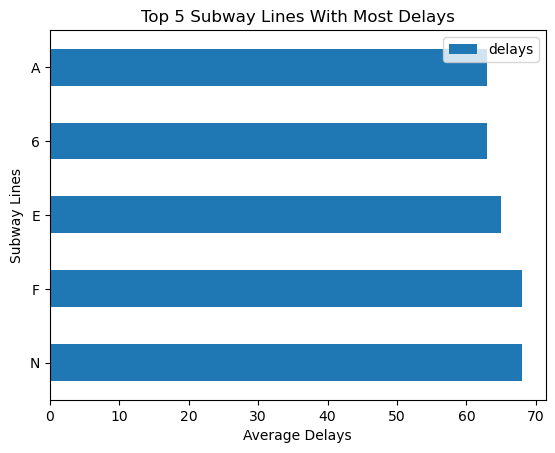

In [332]:
top5.plot(kind='barh')
plt.xlabel('Average Delays')
plt.ylabel('Subway Lines')
plt.title('Top 5 Subway Lines With Most Delays')
plt.show()

### Which trains have the least delays? 

In [334]:
#Top 5 lines with least delays 
least5 = per_line.sort_values('delays',ascending= True).head(5)
least5

,delays
line,
S Fkln,8
S Rock,11
GS,13
JZ,32
3,33


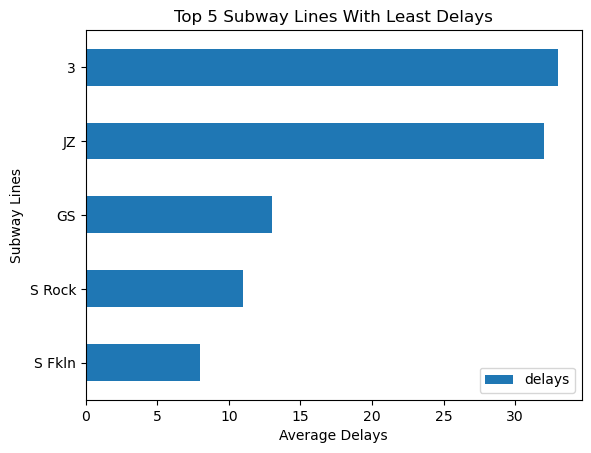

In [335]:
least5.plot(kind = 'barh')
plt.title('Top 5 Subway Lines With Least Delays')
plt.xlabel('Average Delays')
plt.ylabel('Subway Lines')
plt.show()

**More Cleaning**:*extracting the data year and month*

In [337]:
mta_data_copy = mta_data.copy()

In [338]:
#Extracting the the year and month from data 
mta_data_copy['month']= pd.to_datetime(mta_data_copy['month'], errors='coerce')
mta_data_copy['year'] = mta_data_copy['month'].dt.year
mta_data_copy['month_num'] = mta_data_copy['month'].dt.month

### How many delays occur each month?

In [340]:
#calculate average delays per month 
delay_avg_per_month = mta_data_copy.groupby(['year','month_num'])['delays'].mean().reset_index()
delay_avg_per_month['delays']=delay_avg_per_month['delays'].round().astype(int)

In [341]:
type(mta_data_copy['month_num'])

pandas.core.series.Series

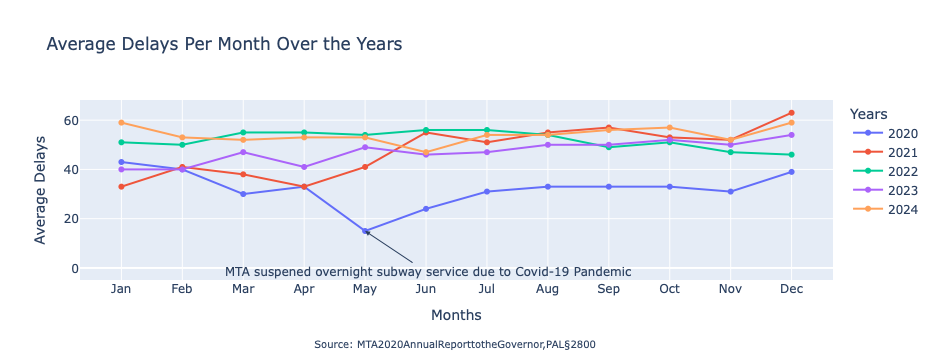

In [527]:
fig = px.line(delay_avg_per_month, x= 'month_num', y= 'delays', color = 'year', markers = True,title= 'Average Delays Per Month Over the Years')
fig.update_xaxes(tickmode='linear', dtick=1) 
fig.update_xaxes(
    tickmode = 'array',
    tickvals=[1, 2, 3, 4, 5,6,7,8,9,10,11,12], 
    ticktext=['Jan', 'Feb', 'Mar', 'Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'] )
fig.update_layout(xaxis_title= 'Months', yaxis_title= 'Average Delays', legend_title_text= "Years")
fig.add_annotation(x= 5, y=15, text = 'MTA suspened overnight subway service due to Covid-19 Pandemic', 
                   showarrow = True, arrowhead=2, ax=60, ay=40, align= 'left')
#Add source
note = 'Source: MTA2020AnnualReporttotheGovernor,PAL§2800'
fig.add_annotation(
    showarrow=False,
    text=note,
    font=dict(size=10), 
    xref='x domain',
    x=0.5,
    yref='y domain',
    y=-0.4
    )
fig.show()

In [343]:
#2024 Delays per month 
delays_24 = delay_avg_per_month[delay_avg_per_month['year'] == 2024]
delays_24

,year,month_num,delays
48,2024,1,59
49,2024,2,53
50,2024,3,52
51,2024,4,53
52,2024,5,53
53,2024,6,47
54,2024,7,54
55,2024,8,54
56,2024,9,56
57,2024,10,57


## Delay Causes Breakdown

In [345]:
#Most common causes of delays? 
delays_causes = mta_data.groupby('subcategory').agg({'delays': 'mean'}).reset_index()
delays_causes['delays']=delays_causes['delays'].round().astype(int)
delays_causes = delays_causes.sort_values(by='delays', ascending=False)
print (delays_causes)

                               subcategory  delays
2                        Crew Availability     140
23                     Subways Maintenance     134
17  Public Conduct, Crime, Police Response     101
20                      Service Management      96
13             Other Operating Environment      90
10                             Other - Sig      85
15                      Persons on Roadbed      43
18                        Rail and Roadbed      39
1         Capital Work - Other Planned ROW      33
4               External Agency or Utility      33
22    Signal Modernization Capital Project      30
21                   Sick/Injured Customer      29
8         Insufficient Supplement Schedule      28
11                    Other Infrastructure      24
9                               Other - CE      22
19                        Service Delivery      19
7                        Inclement Weather      19
12              Other Internal Disruptions      19
6                      Fire, Sm

In [346]:
print(delays_causes.columns)

Index(['subcategory', 'delays'], dtype='object')


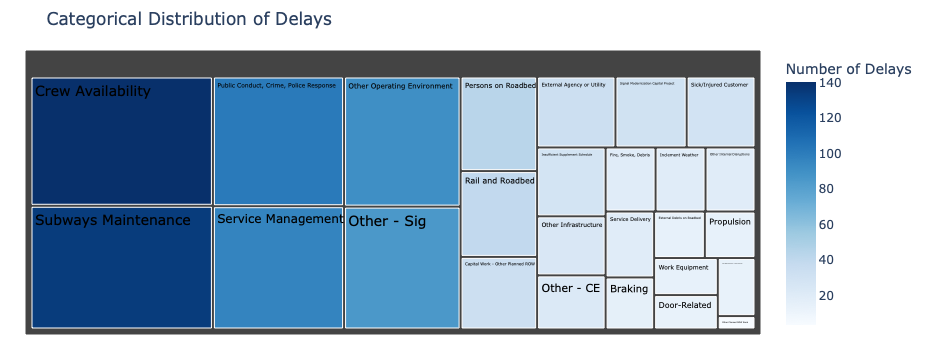

In [545]:
cat = px.treemap( delays_causes,path =['subcategory'],values='delays', color='delays',color_continuous_scale='Blues',
    title='Categorical Distribution of Delays')
cat.update_traces(textinfo='label', hovertemplate='%{label}<br>Delays: %{value}')
cat.update_traces(textfont=dict(size=14,color = 'black'))
cat.update_layout(margin=dict(t=50, l=25, r=25, b=25), coloraxis_colorbar=dict(title="Number of Delays",))
cat.show()

In [427]:
#Top 5 causes of delays 
top5delays = delays_causes.sort_values(by='delays', ascending=False).head(5)
print(top5delays)

                               subcategory  delays
2                        Crew Availability     140
23                     Subways Maintenance     134
17  Public Conduct, Crime, Police Response     101
20                      Service Management      96
13             Other Operating Environment      90


In [429]:
#Causes of Delays by years 
delay_causes = mta_data_copy.groupby(['year','subcategory'])['delays'].mean().reset_index()
delay_causes['delays']=delay_causes['delays'].round().astype(int)
print(delay_causes)

     year                             subcategory  delays
0    2020                                 Braking      11
1    2020        Capital Work - Other Planned ROW      25
2    2020                       Crew Availability      77
3    2020                            Door-Related      10
4    2020              External Agency or Utility      31
..    ...                                     ...     ...
117  2024                   Sick/Injured Customer      38
118  2024    Signal Modernization Capital Project      24
119  2024                     Subways Maintenance     197
120  2024  Train Brake Activation - Cause Unknown      15
121  2024                          Work Equipment      20

[122 rows x 3 columns]


### What are the top 3 causes of delays over the years?

In [431]:
#Top 3 reasons over the years 
top_3 = delay_causes[delay_causes['subcategory'].isin(['Crew Availability','Subways Maintenance','Public Conduct, Crime, Police Response'])]
top_3

,year,subcategory,delays
2,2020,Crew Availability,77
16,2020,"Public Conduct, Crime, Police Response",57
21,2020,Subways Maintenance,89
26,2021,Crew Availability,254
40,2021,"Public Conduct, Crime, Police Response",65
45,2021,Subways Maintenance,91
50,2022,Crew Availability,185
64,2022,"Public Conduct, Crime, Police Response",122
69,2022,Subways Maintenance,132
74,2023,Crew Availability,103


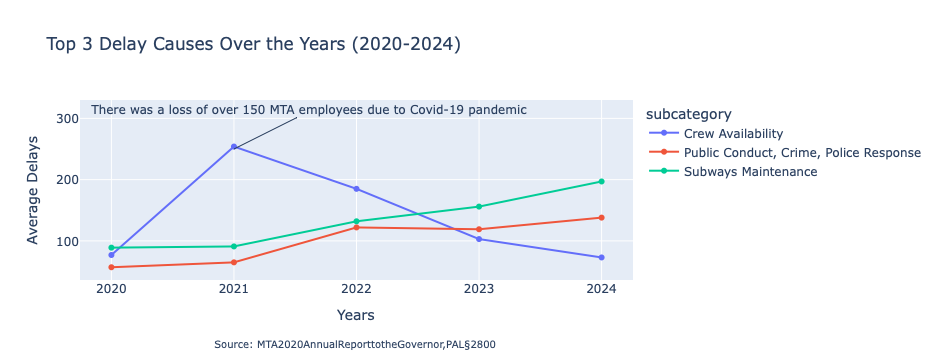

In [543]:
delay = px.line(top_3, x= 'year', y= 'delays', color = 'subcategory', markers = True,title= 'Top 3 Delay Causes Over the Years (2020-2024)')
delay.update_xaxes(tickmode='linear', dtick=1) 
delay.update_layout(xaxis_title= 'Years', yaxis_title= 'Average Delays')
delay.add_annotation(x=2021, y=250, text = 'There was a loss of over 150 MTA employees due to Covid-19 pandemic',
                  ax=80, ay=-40, align ='right')
#Add source
note = 'Source: MTA2020AnnualReporttotheGovernor,PAL§2800'
delay.add_annotation(
    showarrow=False,
    text=note,
    font=dict(size=10), 
    xref='x domain',
    x=0.5,
    yref='y domain',
    y=-0.4
    )
delay.show()

## Seasonal Delays

In [ ]:
#Identifying seasons by months 
def get_season(month_num):
    if month_num in [12, 1, 2]:
        return 'Winter'
    elif month_num in [3, 4, 5]:
        return 'Spring'
    elif month_num in [6, 7, 8]:
        return 'Summer'
    elif month_num in [9, 10, 11]:
        return 'Fall'

In [ ]:
#Create season column
data = mta_data_copy
df = pd.DataFrame(data)
df['season']=df['month_num'].apply(get_season)


In [ ]:
delays_perseason = df.groupby(['season','subcategory']).agg({'delays': 'mean'}).reset_index()

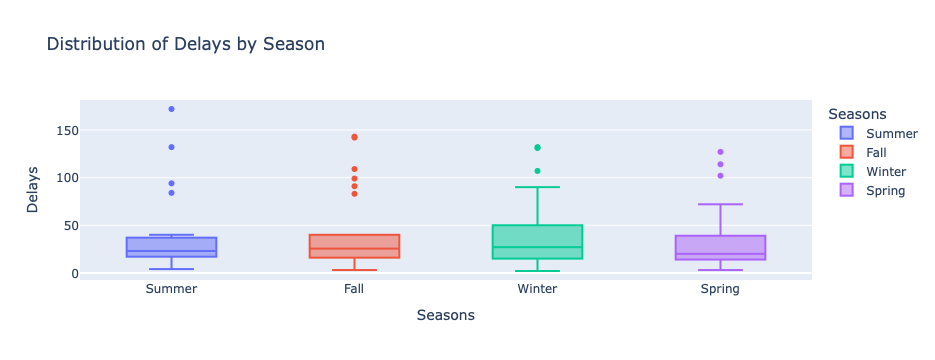

In [451]:
season_dis = px.box(delays_perseason, x='season', y='delays', title='Distribution of Delays by Season', color = 'season',
    labels=dict(season = "Seasons"))
season_dis.update_xaxes(title_text = 'Seasons')
season_dis.update_yaxes(title_text = 'Delays')
season_dis

### Seasonal Observation 
This box plot illustrates the distribution of the amount of delays across different seasons. Winter shows the greatest varaiability in delays, with a couple outliers, suggesting delays are more common and unpredictable during this time. Similar to winter, delays are more common in the Spring as well. Seasons such as Summer and Fall however, have low varaiablity showing during these seasons and trains tend to run with efficency during high-volume months.

### What is the most common delays per season?

In [ ]:
delays_perseason['delays']=delays_perseason['delays'].round().astype(int)
delays_perseason = delays_perseason.sort_values(by='delays', ascending=False)
print (delays_perseason)

In [ ]:
heatmap_data = delays_perseason.pivot(index='subcategory', columns='season', values='delays')

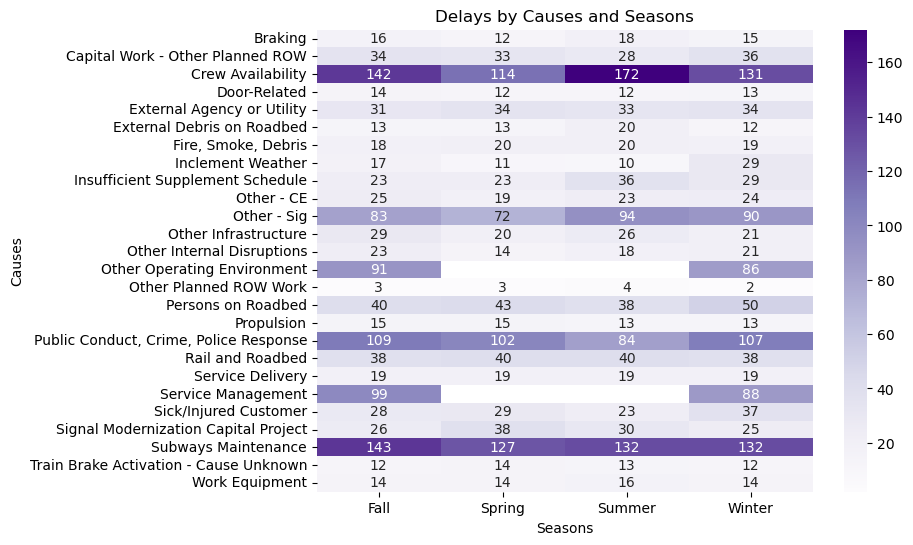

In [445]:
plt.figure(figsize = (8,6))
sns.heatmap(heatmap_data, annot=True,fmt='.0f', cmap='Purples')
plt.title('Delays by Causes and Seasons')
plt.ylabel('Causes')
plt.xlabel('Seasons')
plt.show()

In [ ]:
summer_data = delays_perseason[delays_perseason['season']=='Summer'].head(5)

In [467]:
summer_data

,season,subcategory,delays
52,Summer,Crew Availability,172
71,Summer,Subways Maintenance,132
60,Summer,Other - Sig,94
66,Summer,"Public Conduct, Crime, Police Response",84
67,Summer,Rail and Roadbed,40


In [465]:
fall_data = delays_perseason[delays_perseason['season'] == 'Fall'].head(5)
fall_data

,season,subcategory,delays
23,Fall,Subways Maintenance,143
2,Fall,Crew Availability,142
17,Fall,"Public Conduct, Crime, Police Response",109
20,Fall,Service Management,99
13,Fall,Other Operating Environment,91


In [463]:
spring_data = delays_perseason[delays_perseason['season'] == 'Spring'].head(5)
spring_data

,season,subcategory,delays
47,Spring,Subways Maintenance,127
28,Spring,Crew Availability,114
42,Spring,"Public Conduct, Crime, Police Response",102
36,Spring,Other - Sig,72
40,Spring,Persons on Roadbed,43


In [348]:
winter_data = delays_perseason[delays_perseason['season']=='Winter'].head(5)
winter_data

,season,subcategory,delays
97,Winter,Subways Maintenance,132
76,Winter,Crew Availability,131
91,Winter,"Public Conduct, Crime, Police Response",107
84,Winter,Other - Sig,90
94,Winter,Service Management,88


## Delays per Train Line Divison

In [443]:
#Train lines average delays (Division A vs. Division B)
delaysper_division = mta_data.groupby(['division','line']).agg({'delays':'mean'})
delaysper_division['delays']=delaysper_division['delays'].round().astype(int)
print (delaysper_division)

                   delays
division   line          
A DIVISION 1           48
           2           51
           3           33
           4           46
           5           37
           6           63
           7           51
           GS          13
B DIVISION A           63
           B           49
           C           37
           D           48
           E           65
           F           68
           G           33
           JZ          32
           L           44
           M           34
           N           68
           Q           47
           R           39
           S Fkln       8
           S Rock      11


### What is the average monthly delays over the years per division?

In [351]:
#Average monthly delays over the years per division
delaysper_div = mta_data.groupby(['division', 'year']).agg({'delays':'mean'}).reset_index()
delaysper_div['delays']=delaysper_div['delays'].round().astype(int)
delaysper_div

,division,year,delays
0,A DIVISION,2020,33
1,A DIVISION,2021,47
2,A DIVISION,2022,50
3,A DIVISION,2023,46
4,A DIVISION,2024,54
5,B DIVISION,2020,32
6,B DIVISION,2021,48
7,B DIVISION,2022,53
8,B DIVISION,2023,48
9,B DIVISION,2024,54


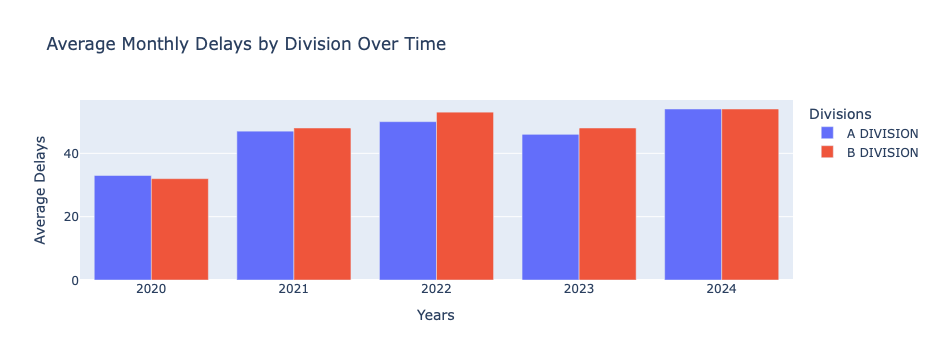

In [539]:
division = px.bar(delaysper_div, x='year', y='delays',color='division',barmode = 'group', title='Average Monthly Delays by Division Over Time',
            labels=dict(division = "Divisions"))
division.update_xaxes(title_text = 'Years')
division.update_yaxes(title_text = 'Average Delays')
division.show()

## Recommendations 🚆

 #### Seasonal Maintenance & Operations 🛠️ 

As cooler weather approaches, the MTA should increase the frequency of train inspections and preventive maintenance. Data suggests that Fall and Winter delays are often caused by subway maintenance. Conducting seasonal maintenance during off-peak hours (10:00 PM - 4:00AM) a key strategy for reducing disruptions. Another operational improvement could involve rotating train usage more effectively to reduce strain on specific lines and allow smoother transitions between through-services, improving overall efficiency.

 #### Optimizing Scheduling by Season 🕒

In low-variability seasons like Summer, when delays are more predictable, the MTA has an opportunity to optimize scheduling. While crew availability is a common cause of delays during this time, the agency can address this by hiring additional staff for seasonal support. Additionally, the MTA should consider deploying more trains during peak commuting hours — specifically from 7:00 AM to 10:00 AM and 4:00 PM to 7:00 PM — to meet rider demand and reduce crowding-related slowdowns.

 #### Enhancing Public Safety 🚨

Public safety remains a top priority for MTA riders. Reports show an increase in public conduct violations, crime, and response delays over time. While the NYPD has responded by increasing patrols on trains and platforms, further steps are needed.The MTA and NYPD should ensure that there are dedicated, responsive patrol teams assigned to transit stations, capable of de-escalating and responding to incidents swiftly. There should also be a review of legal and procedural follow-through to ensure that repeat offenders face stronger consequences, deterring future incidents.

#### Technology & Surveillance 🎥

Security infrastructure can also be improved through more frequent seasonal inspections of surveillance cameras. Additionally, the use of AI-based detection systems can enhance monitoring precision — such as alerting operations teams when a camera’s battery is low or when unusual activity is detected. This proactive approach ensures minimal downtime and quicker response to safety threats.

